In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Wandb Connnection

In [2]:
!pip install -q wandb transformers sentencepiece

from kaggle_secrets import UserSecretsClient
import wandb

user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=wandb_api)

PROJECT = "DL-24f1000881-notebook-t22026"
ENTITY = "24f1000881-indian-institute-of-technology-madras"

def start_run(run_name, config_dict):
    run = wandb.init(
        project=PROJECT,
        entity=ENTITY,
        name=run_name,
        config=config_dict,
        reinit=True
    )
    return run

print("W&B login successful")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


W&B login successful


# Import Libraries

In [3]:
import os
import re
import sys
import joblib
import warnings

os.makedirs("saved_models", exist_ok=True)
warnings.filterwarnings("ignore")

!{sys.executable} -m pip install -q graphviz

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from graphviz import Digraph

# Configuration

In [4]:
import random

SEED = 42
OPTION_LABELS = ["A", "B", "C", "D", "E"]
LABEL2ID = {"A":0, "B":1, "C":2, "D":3, "E":4}
ID2LABEL = {v:k for k, v in LABEL2ID.items()}

MAX_FEATURES = 30000
NGRAM_RANGE = (1, 2)
MAX_ITER = 1200

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED)

print("Configuration complete. Notebook optimized for TF-IDF + Logistic Regression.")

pd.set_option("display.max_colwidth", 300)
sns.set_style("whitegrid")

Configuration complete. Notebook optimized for TF-IDF + Logistic Regression.


# Dataset Overview 

In [5]:
# Loading Data


train_path = "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
test_path = "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
sample_path = "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_df = pd.read_csv(sample_path)

overview_df = pd.DataFrame({
    'Dataset': ['Train', 'Test', 'Sample Submission'],
    'Questions / Rows': [len(train_df), len(test_df), len(sample_df)],
    'Features': [
        'id + prompt + A-E + answer',
        'id + prompt + A-E',
        'ID + Prediction'
    ]
})

display(overview_df)

,Dataset,Questions / Rows,Features
0,Train,2000,id + prompt + A-E + answer
1,Test,500,id + prompt + A-E
2,Sample Submission,500,ID + Prediction


# Exploratory Data Analysis

In [6]:
print("Train columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

print("\nMissing values in train:")
display(train_df.isnull().sum())

print("\nMissing values in test:")
display(test_df.isnull().sum())

Train columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
Test columns : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']

Missing values in train:


id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64


Missing values in test:


id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

### Answer Distribution

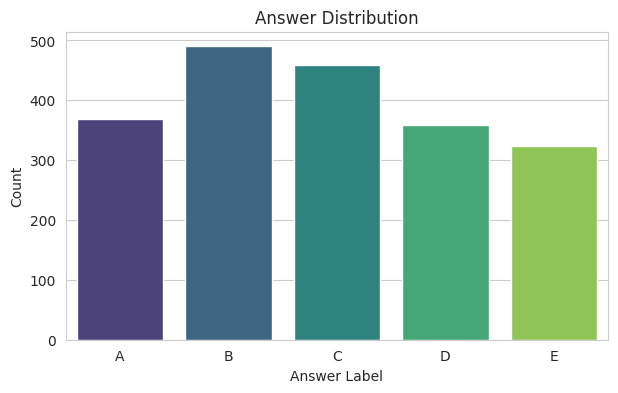

In [7]:
plt.figure(figsize=(7, 4))
answer_counts = train_df['answer'].value_counts().sort_index()
sns.barplot(x=answer_counts.index, y=answer_counts.values, palette='viridis')
plt.title('Answer Distribution')
plt.xlabel('Answer Label')
plt.ylabel('Count')
plt.show()

### Prompt and Option length Analysis

In [8]:
def word_count(text):
    return len(str(text).split())

def char_count(text):
    return len(str(text))

def unique_word_count(text):
    return len(set(str(text).split()))

train_df['prompt_word_count'] = train_df['prompt'].apply(word_count)
train_df['prompt_char_count'] = train_df['prompt'].apply(char_count)
train_df['prompt_unique_words'] = train_df['prompt'].apply(unique_word_count)

prompt_stats = pd.DataFrame({
    'Metric': [
        'Average question length (words)',
        'Shortest question length (words)',
        'Longest question length (words)',
        'Average question length (characters)',
        'Average unique words per question'
    ],
    'Value': [
        round(train_df['prompt_word_count'].mean(), 2),
        int(train_df['prompt_word_count'].min()),
        int(train_df['prompt_word_count'].max()),
        round(train_df['prompt_char_count'].mean(), 2),
        round(train_df['prompt_unique_words'].mean(), 2)
    ]
})

display(prompt_stats)

,Metric,Value
0,Average question length (words),18.15
1,Shortest question length (words),3.00
2,Longest question length (words),51.00
3,Average question length (characters),117.67
4,Average unique words per question,15.74


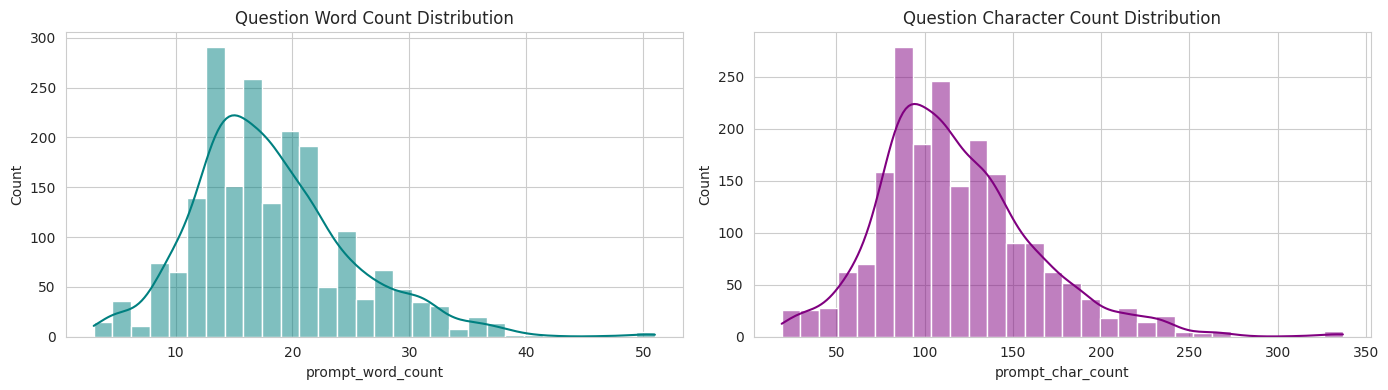

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train_df['prompt_word_count'], bins=30, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Question Word Count Distribution')

sns.histplot(train_df['prompt_char_count'], bins=30, kde=True, color='purple', ax=axes[1])
axes[1].set_title('Question Character Count Distribution')

plt.tight_layout()
plt.show()

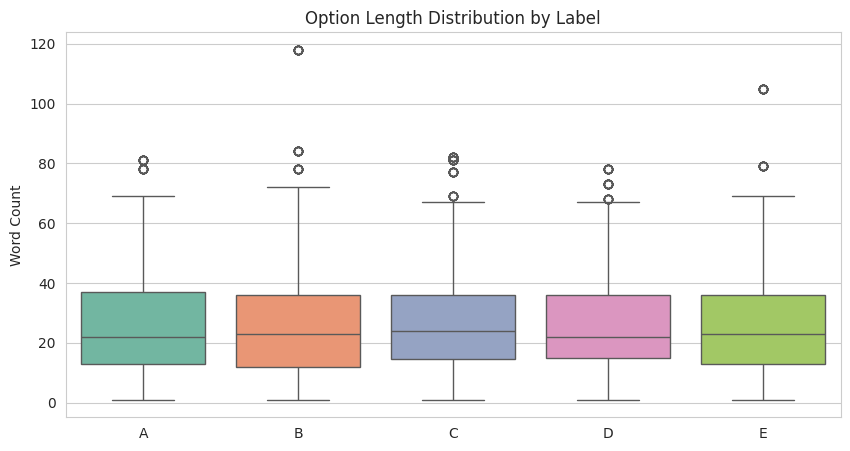

In [10]:
option_word_df = pd.DataFrame({
    label: train_df[label].astype(str).apply(word_count)
    for label in OPTION_LABELS
})

plt.figure(figsize=(10, 5))
sns.boxplot(data=option_word_df, palette='Set2')
plt.title('Option Length Distribution by Label')
plt.ylabel('Word Count')
plt.show()

In [11]:
all_prompt_text = train_df['prompt'].astype(str).str.lower().tolist()

vocab_counter = Counter()
for text in all_prompt_text:
    vocab_counter.update(text.split())

print('Vocabulary size:', len(vocab_counter))
display(pd.DataFrame(vocab_counter.most_common(30), columns=['word', 'count']))

Vocabulary size: 931


,word,count
0,the,5528
1,is,1986
2,what,1809
3,of,1514
4,correct,893
5,following,746
6,in,714
7,answer:,608
8,option:,608
9,and,448


In [12]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=20)
bigram_matrix = bigram_vectorizer.fit_transform(all_prompt_text)
bigram_counts = np.asarray(bigram_matrix.sum(axis=0)).ravel()
bigram_df = pd.DataFrame({
    'bigram': bigram_vectorizer.get_feature_names_out(),
    'count': bigram_counts
}).sort_values('count', ascending=False).reset_index(drop=True)
display(bigram_df)

trigram_vectorizer = CountVectorizer(ngram_range=(3, 3), stop_words='english', max_features=20)
trigram_matrix = trigram_vectorizer.fit_transform(all_prompt_text)
trigram_counts = np.asarray(trigram_matrix.sum(axis=0)).ravel()
trigram_df = pd.DataFrame({
    'trigram': trigram_vectorizer.get_feature_names_out(),
    'count': trigram_counts
}).sort_values('count', ascending=False).reset_index(drop=True)
display(trigram_df)

,bigram,count
0,listed options,388
1,based given,376
2,given context,376
3,following choices,369
4,possible answer,316
5,pick best,316
6,best possible,316
7,accurate option,309
8,select accurate,309
9,identify correct,302


,trigram,count
0,based given context,376
1,best possible answer,316
2,pick best possible,316
3,select accurate option,309
4,identify correct statement,302
5,determine correct option,299
6,choose correct answer,292
7,following statements accurately,71
8,statements accurately describes,62
9,option following statements,28


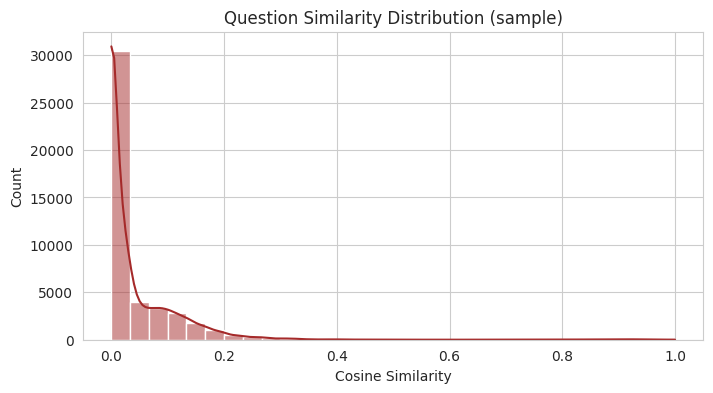

In [13]:
sim_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
sim_matrix = sim_vectorizer.fit_transform(train_df['prompt'].astype(str).head(300))
cosine_mat = cosine_similarity(sim_matrix)
sim_values = cosine_mat[np.triu_indices_from(cosine_mat, k=1)]

plt.figure(figsize=(8, 4))
sns.histplot(sim_values, bins=30, kde=True, color='brown')
plt.title('Question Similarity Distribution (sample)')
plt.xlabel('Cosine Similarity')
plt.show()

In [14]:
def repeated_options(row):
    opts = [str(row[c]).strip().lower() for c in OPTION_LABELS]
    return len(set(opts)) < 5

duplicate_report = pd.DataFrame({
    'Check': [
        'Duplicate IDs',
        'Duplicate prompts',
        'Rows with repeated options'
    ],
    'Value': [
        int(train_df['id'].duplicated().sum()),
        int(train_df['prompt'].duplicated().sum()),
        int(train_df.apply(repeated_options, axis=1).sum())
    ]
})

display(duplicate_report)

,Check,Value
0,Duplicate IDs,0
1,Duplicate prompts,242
2,Rows with repeated options,0


### Text Cleaning

In [15]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s\-\?\!\.,:;]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_df, test_df]:
    df['prompt'] = df['prompt'].apply(clean_text)
    for col in OPTION_LABELS:
        df[col] = df[col].apply(clean_text)

In [16]:
# Train-Validation Split

unique_ids = train_df["id"].unique()
train_ids, val_ids = train_test_split(unique_ids, test_size=0.2, random_state=SEED)

train_main = train_df[train_df["id"].isin(train_ids)].reset_index(drop=True)
val_main = train_df[train_df["id"].isin(val_ids)].reset_index(drop=True)

print("Train questions:", train_main.shape)
print("Validation questions:", val_main.shape)

Train questions: (1600, 11)
Validation questions: (400, 11)


# Evaluation Metrics

In [17]:
def apk(actual, predicted, k=3):
    predicted = predicted[:k]
    for i, p in enumerate(predicted):
        if p == actual:
            return 1.0 / (i + 1)
    return 0.0

def mapk(actuals, predictions, k=3):
    return np.mean([apk(a, p, k) for a, p in zip(actuals, predictions)])

def make_top3_predictions(df, score_col):
    ranked = (
        df.sort_values(["id", score_col], ascending=[True, False])
          .groupby("id")["option_label"]
          .apply(list)
          .reset_index()
    )
    ranked["top3"] = ranked["option_label"].apply(lambda x: x[:3])
    return ranked[["id", "top3"]]

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "loss": log_loss(y_true, y_prob, labels=[0, 1])
    }

In [18]:
# building long format for ranking models
def build_long_format(df, is_train=True):
    rows = []
    labels = ["A", "B", "C", "D", "E"]

    for _, row in df.iterrows():
        for label in labels:
            combined_text = (
                f"question: {row['prompt']} "
                f"[SEP] option: {row[label]}"
            )

            item = {
                "id": row.get("id", None),
                "prompt": row["prompt"],
                "option_label": label,
                "option_text": row[label],
                "retrieved_context": "", 
                "combined_text": combined_text
            }

            if is_train and "answer" in row:
                item["target"] = 1 if row["answer"] == label else 0

            rows.append(item)

    return pd.DataFrame(rows)

# 2. ACTUALLY CREATE THE LONG DATAFRAMES (Run this line!)
train_long = build_long_format(train_main, is_train=True)
val_long = build_long_format(val_main, is_train=True)
test_long = build_long_format(test_df, is_train=False)

print("Train long shape:", train_long.shape)

Train long shape: (8000, 7)


## Model 1 - Architecture

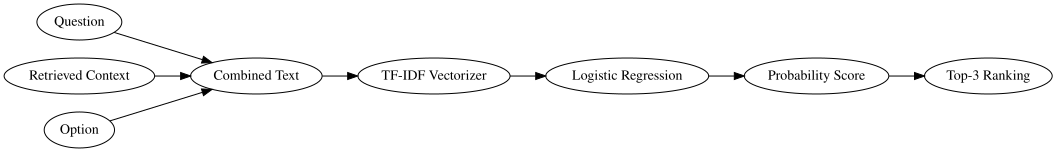

In [19]:
from graphviz import Digraph

dot = Digraph("Logistic_Regression", format="png")

dot.attr(rankdir="LR", fontsize="12")

dot.node("A", "Question")
dot.node("B", "Retrieved Context")
dot.node("C", "Option")
dot.node("D", "Combined Text")
dot.node("E", "TF-IDF Vectorizer")
dot.node("F", "Logistic Regression")
dot.node("G", "Probability Score")
dot.node("H", "Top-3 Ranking")

dot.edges([
    ("A","D"),
    ("B","D"),
    ("C","D"),
    ("D","E"),
    ("E","F"),
    ("F","G"),
    ("G","H")
])

display(dot)

# Model 1 - TF-IDF + Logistic Regression


In [20]:
lr_run = start_run(
    "model1_tfidf_logistic_regression",
    {
        "model_type": "your_choice",
        "model_name": "TF-IDF + Logistic Regression",
        "max_features": 30000,
        "ngram_range": "1-2"
    }
)

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_lr = tfidf.fit_transform(train_long["combined_text"])
X_val_lr = tfidf.transform(val_long["combined_text"])

y_train_lr = train_long["target"].values
y_val_lr = val_long["target"].values

lr_model = LogisticRegression(
    max_iter=1200,
    class_weight="balanced",
    random_state=SEED
)

lr_model.fit(X_train_lr, y_train_lr)

val_lr = val_long.copy()
val_lr["score"] = lr_model.predict_proba(X_val_lr)[:, 1]

lr_binary_metrics = compute_binary_metrics(y_val_lr, val_lr["score"].values)

lr_top3 = make_top3_predictions(val_lr, "score")
lr_eval = lr_top3.merge(val_main[["id", "answer"]], on="id")
lr_map3 = mapk(lr_eval["answer"].tolist(), lr_eval["top3"].tolist())

print("Model 1 - TF-IDF Logistic Regression")
print("Validation Loss    :", round(lr_binary_metrics["loss"], 5))
print("Validation Accuracy:", round(lr_binary_metrics["accuracy"], 5))
print("Validation F1      :", round(lr_binary_metrics["f1"], 5))
print("Validation MAP@3   :", round(lr_map3, 5))

joblib.dump(lr_model,"saved_models/logistic_regression_model.pkl")
wandb.save("saved_models/logistic_regression_model.pkl")

wandb.log({
    "val_loss": lr_binary_metrics["loss"],
    "val_accuracy": lr_binary_metrics["accuracy"],
    "val_f1": lr_binary_metrics["f1"],
    "val_map3": lr_map3
})

lr_run.finish()

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260721_054810-zlhypwa0
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model1_tfidf_logistic_regression
wandb: ⭐️ View project at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/zlhypwa0
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: updating run metadata; uploading console lines 0-4


Model 1 - TF-IDF Logistic Regression
Validation Loss    : 0.38898
Validation Accuracy: 0.95
Validation F1      : 0.88584
Validation MAP@3   : 0.97167


wandb: uploading history steps 0-0, summary, console lines 5-5
wandb: 
wandb: Run history:
wandb: val_accuracy ▁
wandb:       val_f1 ▁
wandb:     val_loss ▁
wandb:     val_map3 ▁
wandb: 
wandb: Run summary:
wandb: val_accuracy 0.95
wandb:       val_f1 0.88584
wandb:     val_loss 0.38898
wandb:     val_map3 0.97167
wandb: 
wandb: 🚀 View run model1_tfidf_logistic_regression at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/zlhypwa0
wandb: ⭐️ View project at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 1 other file(s)
wandb: Find logs at: ./wandb/run-20260721_054810-zlhypwa0/logs


# Inferences for Models

In [21]:
# Submission Helper Function
def save_submission_from_ranked_lists(ids, ranked_lists, filename='submission.csv'):
    submission = pd.DataFrame({
        'ID': ids,
        'Prediction': [' '.join(x[:3]) for x in ranked_lists]
    })
    submission.to_csv(filename, index=False)
    return submission

# Final inference: Logistic Regression
full_train_long = build_long_format(train_df, is_train=True)
full_test_long = build_long_format(test_df, is_train=False)

final_tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES, 
    ngram_range=NGRAM_RANGE, 
    stop_words="english"
)
X_full = final_tfidf.fit_transform(full_train_long["combined_text"])
y_full = full_train_long["target"].values
X_test = final_tfidf.transform(full_test_long["combined_text"])

final_lr = LogisticRegression(
    max_iter=MAX_ITER, 
    class_weight="balanced", 
    random_state=SEED
)
final_lr.fit(X_full, y_full)

full_test_long["score"] = final_lr.predict_proba(X_test)[:, 1]

ranked = (
    full_test_long.sort_values(["id", "score"], ascending=[True, False])
    .groupby("id")["option_label"]
    .apply(list)
    .reset_index()
)

submission = save_submission_from_ranked_lists(
    ranked["id"].tolist(),
    ranked["option_label"].tolist(),
    filename='submission.csv'
)

display(submission.head())

,ID,Prediction
0,1,A E C
1,2,B E A
2,3,B E D
3,4,E C A
4,5,C A B


In [22]:
# Final Check

print("Sample submission columns:", sample_df.columns.tolist())
print("Our submission columns   :", submission.columns.tolist())

submission["num_labels"] = submission["Prediction"].apply(lambda x: len(x.split()))
print(submission["num_labels"].value_counts())

display(submission.head())

Sample submission columns: ['ID', 'Prediction']
Our submission columns   : ['ID', 'Prediction']
num_labels
3    500
Name: count, dtype: int64


,ID,Prediction,num_labels
0,1,A E C,3
1,2,B E A,3
2,3,B E D,3
3,4,E C A,3
4,5,C A B,3
